

# Project Data Science
***Auteurs : DIALLO Bintou, RIPOLL Thomas***

***Thématique Business:***

Fidélisation et anticipation de la perte de clientèle dans les télécoms

***Contexte métier:***

Telco est une entreprise de télécommunications qui fournit des services essentiels de téléphonie et d'accès à internet. Son rôle principal est d'assurer une connectivité fiable tout en accompagnant ses abonnés au quotidien. À travers son service client, elle se charge de résoudre d'éventuelles pannes techniques et de gérer toutes les demandes liées aux abonnements, aux équipements ou à la facturation.

***Jeu de données:***

* **Source de données :** [Kaggle.com](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
* **Nom du dataset :** `WA_Fn-UseC_-Telco-Customer-Churn`
* **Volume :** 977,5 Ko, 7 043 lignes
* **Variables :** 23 variables au total (String : 12, Boolean : 5, Integer : 2, Other : 2). Ces variables se divisent en trois grandes catégories :
    * **Données démographiques :** Sexe, âge, situation familiale.
    * **Services souscrits :** Téléphone, lignes multiples, internet, sécurité en ligne, support technique, streaming, etc.
    * **Informations de compte :** Ancienneté du client, type de contrat, méthode de paiement, facturation mensuelle et totale.

***Problématique business:***

Nous sommes Data Scientist au sein d’une entreprise de télécommunication Telco. Notre entreprise souhaiterais prévoir les moments où les clients seraient les plus à même de résilier leurs abonnements et services souscrits au sein de notre entreprise, afin de savoir quand leur proposer des offres, ou mettre en place différentes techniques marketing pour de les fidéliser de nouveau, et éviter qu’ils ne se désabonnent. Parvenir à prédire ceci permettrait à l’entreprise d’éviter une perte de clients et donc une potentielle baisse de leur chiffre d’affaire.


***Objectif Data Science:***

1. Réaliser une analyse exploratoire (EDA) pour identifier les facteurs qui influencent le plus le départ d'un client (ex: type de contrat, absence de support technique, facturation élevée).

2. Développer un modèle de classification binaire (Supervised Learning) capable de prédire avec précision la probabilité de désabonnement d'un client (Churn = Oui ou Non) à partir de ses caractéristiques et de son historique.

##  Analyse exploratoire des données (EDA)
À réaliser dans un notebook Jupyter (.ipynb) avec analyse de la structure, statistiques
descriptives, valeurs manquantes, visualisations, corrélations, outliers et hypothèses.

### EDA-1 : Analyse de la structure du dataset
Vérification de la taille des données, du nom des colonnes et du type de variables:

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

#1) Chargement du fichier de données
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

#2) Analyse de la structure (Taille et types de données)
print("Taille du dataset :", df.shape)
print("-" * 40)
df.info()

#3) Affichage des 5 premières lignes pour un aperçu
display(df.head())

print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")


Taille du dataset : (7043, 21)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract         

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Le dataset contient 7043 lignes et 21 colonnes.


Interprétation : Nous commençons par faire cet étape afin d'avoir un aperçu global de notre dataset et des données qu'il contient, ainsi que le profil client.

Volume et pertinence : Le dataset contient 7043 lignes et 21 colonnes. C'est un volume de données tout à fait satisfaisant pour entraîner notre algorithme.

 On peut voir qu'une grande partie des données est représentée sous forme "Yes" ou "Non", semblable à un fonctionnement booléen (par exemple : La colonne "partner").

 Le résultat de la colonne " Non-Null Count" nous confirme que notre dataset est bien remplie pour toute sles colonnes

#EDA-2 : Statistiques descriptives

Analyse des moyennes, valeurs minimales et maximales pour comprendre la distribution de nos clients.

In [56]:
#stats des colonnes avec des nombres (moyenne, min, max, etc.)
display(df.describe())

#sats des colonnes de texte (nb de categories uniques, categorie la + frequente)
display(df.describe(include='O'))

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


Interprétation :

##Variables numériques :

- On remarque que l'ancienneté (tenure) moyennes de nos clients est de 32 mois mais qu'il y a de gros écarts : le minimum allant de 0 (clients tout nouveux) et maximum atteignant 72

- Pour ce qui est du prix payé, la facture mensuelle varie de 18,25 à 118,75, avec une moyenne autour de 64,76

- Etant donné que SeniorCitizen est un booléen : valeur à 0 ou 1. La moyenne à environ 0.16 nous fait comprendre que nous avons environ 16% de nos clients étant seniors

##Variables catégorielles :    

- Pour notre colonne la plus importante : churn, nous pouvons voir que la valeur la plus fréquente est "No", ce qui signifie que la plupart des clients restent et nous pouvons voir que nous avons un jeu de données déséquilibré de par le fait qu'il y ait plus de "no" que de "yes".

- Nous pouvons aussi voir que le type de contrat le plus répendu est le "month-to-month" : c'est trop tôt pour affirmer si cela a un impact sur la volonté d'un utilisateur de partir mais celareste bien à garder en têtepour de futures hypothèses.

### EDA-3. Gestion des valeurs manquantes et recherches des doublons

Recherche des données vides dans notre dataset. Nous avons repéré un problème de format sur les colonnes :
1.  TotalCharges : Objet -> numerique
2.  SeniorCitiezn : Numerique -> Catégory (On remplace également 0 ou 1 par "Yes" ou "Non")
3. Colonnes Objets : Objet -> catégotry (On remarque sur ses colonnes qu'il n'y a que 4 valeurs uniques au maximun, c'est donc le choix le plus judicieux )

In [57]:
#cast de TotalCharges en numérique car avant c'était txt
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remplacer les 0 et 1 par "No" et "Yes"
# pour garder une belle cohérence avec les autres variables comme "Partner" ou "Dependents"
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('category')

#Transformation des types objets en category pour plus de coherence
colonnes_textes = df.select_dtypes(include=['object']).columns
for col in colonnes_textes:
    df[col] = df[col].astype('category')

# nb de valeurs manquantes dans chaque colonne
print(df.isnull().sum())

#suppresion valeurs manquantes
df = df.dropna()

# Recherche des doublons
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)
df = df.drop_duplicates()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Nombre de doublons : 0


Interprétation :

- Le fait de forcer en valeur numériques la colone TotalCharges a mis en évidence les espaces vides, les transformant en valeurs nulles, indiquant qu'il y a 11 valeurs nulles. Nous les avons alors supprimé, leur nombre étant dérisoire comparé au nombre totale de lignes que nous avons, cela ne posera pas de soucis.

- On a remplacé le 0 et le 1 du tableau pour avoir le même focntionnement dans tout le tableau.

- EN remplaçant toutes les colonnes de type texte en type category nous permettons qu'il y a moins de type à gérer, permettant une amelioration de la performance en uniformisant

- L'absence de doublon : La vérification nous confirme que notre jeu de données est sain à ce niveau-là, avec 0 ligne dupliquée.



In [58]:
#Verification des types des colonnes après les transformations
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   category
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   category
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   category
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-nu

Interprétation :    

Maintenant que notre tableau est propre et allégé. Chaque colonne a enfin le bon format : des vrais nombres pour les prix et l'ancienneté, et des catégories pour le texte.

### EDA-4. Recherche des Outliers (=Valeurs aberrantes)
Nous cherchns à repérer si certains clients ont des facturations ou des anciennetés anormales. Afin d'éviter que des variable extrêmes ne faussent nos analyses.

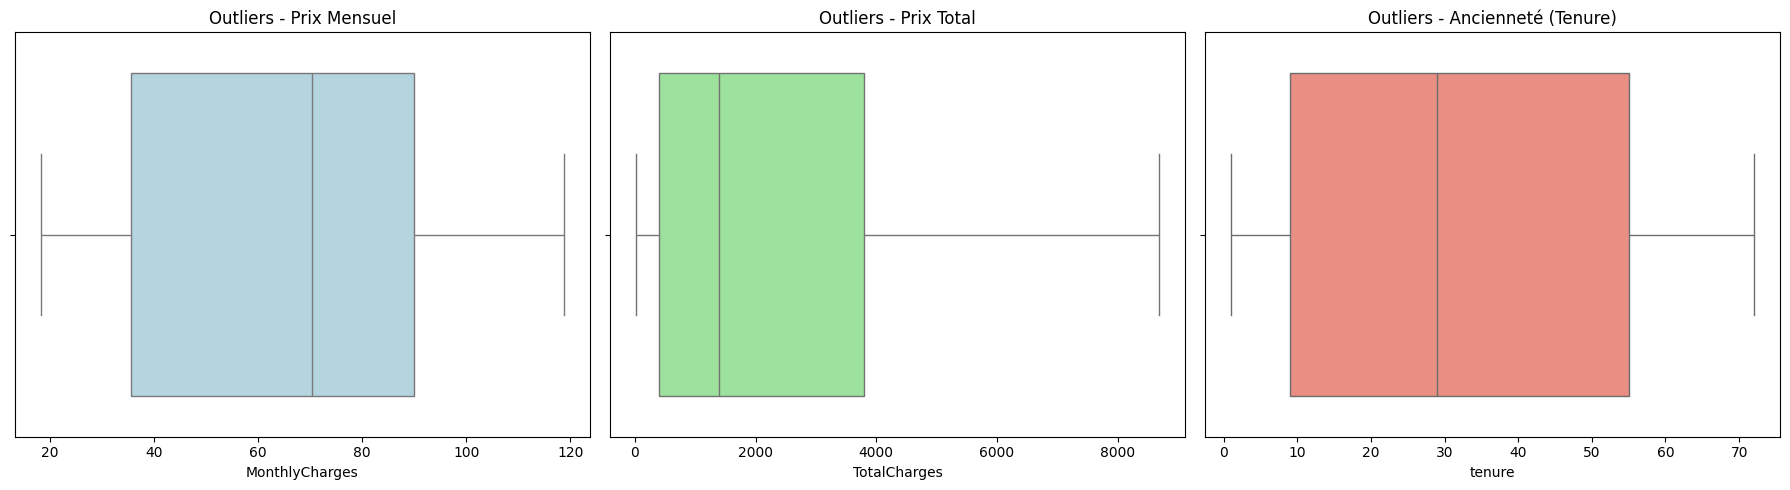

In [59]:
# On augmente un peu la largeur (18 au lieu de 12) pour que les 3 soient bien lisibles
plt.figure(figsize=(18, 5))

# 1. Boxplot pour les charges mensuelles (Grille 1x3, Position 1)
plt.subplot(1, 3, 1)
sns.boxplot(x=df['MonthlyCharges'], color='lightblue')
plt.title('Outliers - Prix Mensuel')

# 2. Boxplot pour le total payé (Grille 1x3, Position 2)
plt.subplot(1, 3, 2)
sns.boxplot(x=df['TotalCharges'], color='lightgreen')
plt.title('Outliers - Prix Total')

# 3. Boxplot pour l'ancienneté (Grille 1x3, Position 3)
plt.subplot(1, 3, 3)
sns.boxplot(x=df['tenure'], color='salmon')
plt.title('Outliers - Ancienneté (Tenure)')

plt.tight_layout()
plt.show()

Interprétation :    

Nous pouvons voir à parir de nos graphiques d'outliers que nos données pour le prix mensuel, le prix toltal et l'ancienneté ne sont pas abbérentes (de par l'absence de points en dehors de nos limites et forme nette de notre graphique)
Notre graphique ne contient donc pas de valeurs aberrantes, selon les métriques que nous avons choisies.

Ce que ça peut signifier :    

- L'absence d'outliers signifie d'abord qu'il n'y a pas eu d'erreur informatique ou de faute de frappe au moment où les données ont été rentrées (par exemple : une personne payant un prix de 999999 pour son abonnement)

- La politique tarifaire de notre entreprise ne suit pas une évolution "étrange", les fourchettes de prix peuvent être vues comme classiques, le contraire ayant pu avoir une incidence sur le churn de certains clients.

### EDA-5 Visualisations
Nous souhaitons faire des visualisations pour essayer comprendre ce qui pousse un client au désabonnement

/tmp/ipykernel_431/1045986789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


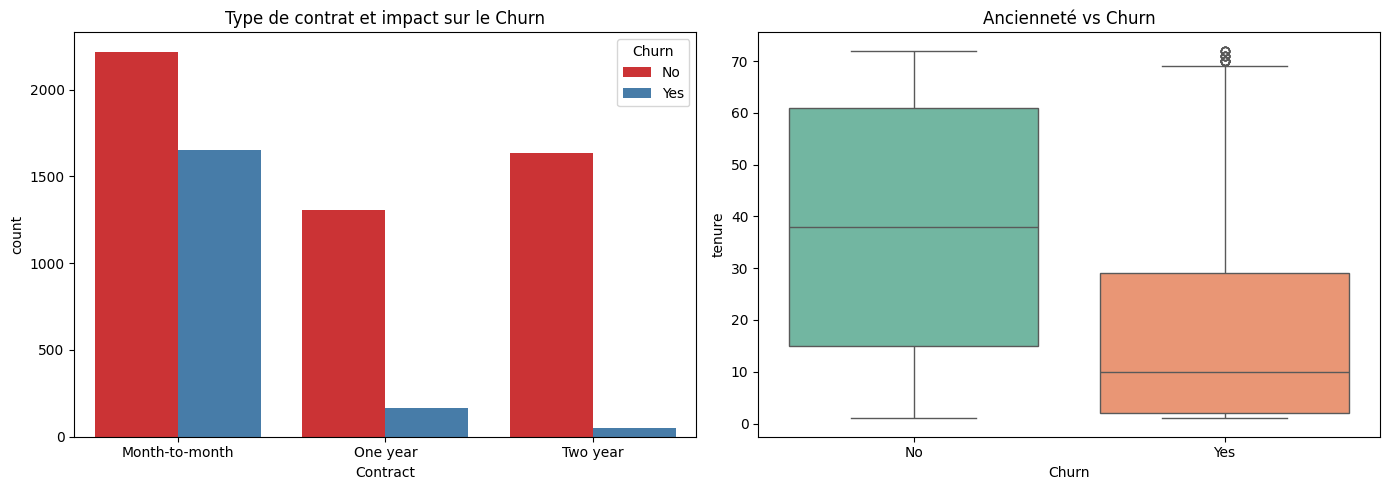

In [60]:
plt.figure(figsize=(14, 5))

# 1er Graphique : L'impact du type de contrat
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Type de contrat et impact sur le Churn')

# 2ème Graphique : Impact de l'ancienneté
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Ancienneté vs Churn')

plt.tight_layout()
plt.show()


Interprétation :    

Graphique 1 :     
- Le premier graphique montre une tendance trsè forte : la majorité des clients qui vont nous quitter sont généralement des clients ayant un type d'abonneent de type "month-to-month".
- Les clients ayant des abonnements les engageant sur une année complète ou deux années complètes sont ceux qui se désabonnent le moins de nos services.

Graphique 2 :
- Le deuxième graphique nous montre que la majorité des personnes qui ont en effet rélisilié leur abonnement (=churn) étaient dans la majorité des personnes ayant une faible ancienneté (allant de 0 à 30 mois et oscillant le plus souvent autour des 10 mois, et avec quelques valeurs n'entrant pas dans cette généralisation, comme le montre les cercles à l'extrémité de l'axe).

- Tandis que ceux maintenant leur abonnement ont souvent une ancienneté allant de 15 à 60 mois (ce qui est en moyenne plus long que lancienneté des personnes résiliant leurs abonnements).

- On peut donc en déduire que les clients ayant l'ancienneté la moins élevée sont ceuxx qui sont les plus susceptibles de nous quitter, tandis que la tendance est que plus les clients ont d'ancienneté, plus ils sont fidélisés et moins ils résilient nos services.

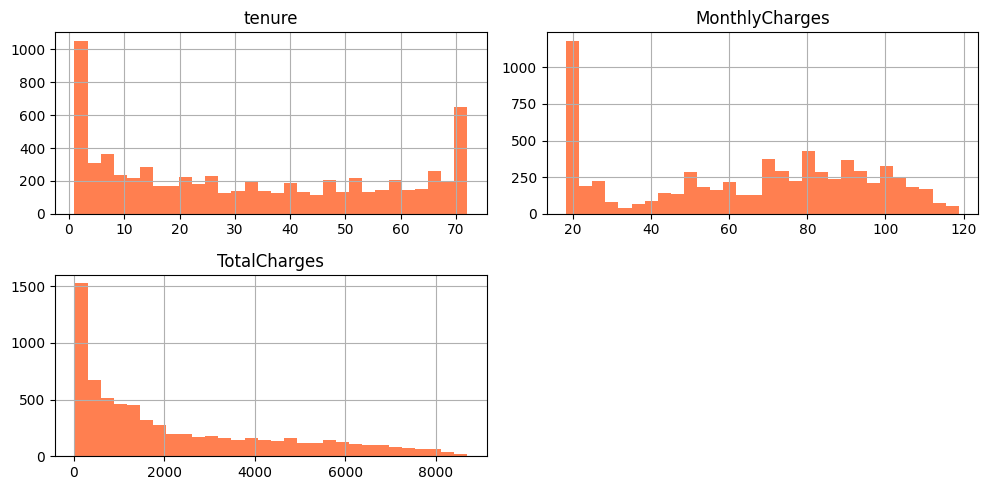

In [61]:
# Histogrammes pour analyser les distributions
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=30, figsize=(10, 5), color='coral')
plt.tight_layout()
plt.show()

Interprétation :    

- Ancienneté (tenure) : On observe un pic des clients très récents (vers 0) ainsi qu'un pic des clients très anciens (vers 70). On peut en déduire que le défi de l'enteprise serait de maintenir les nouveaux clients assez longtemps pour qu'ils deviennent des clients de longue datemoins de chance de se désinscrire de nos services une fois fidélisés.

- Monthly Charges : On peut voir qu'une grande partie des personnes payent un abonnement d'une valeur de 20 tandis qu'un grand étalé groupe de personnes payent plus cher des prix allant de 40 à 100. Moins de personnes paynt dans les environs de 40 ou 120. Une interprétatin possible pourrait être que beaucoup de personnes ne payent qu'un seul abonneme nt (expliquant le pic d'abonnements peu cher), tandis que certaines autres personnes font des regroupements d'offres.

- TotalCharges :    La majorité des données se rrouvent sur la droite et même près de 0. Ce qui s'explique par la fait que la majorité des clients sont des clients avec peu d'ancienneté (comme vu dans de précédents graphiques) ce qui explique que la majorité des clients n'ont pas un total de dépense très élevé.

In [62]:
#preuve numérique : calcul de la skewness
skewness_total = df['TotalCharges'].skew()
print(f"La skewness de TotalCharges est de : {skewness_total:.2f}")

skewness_tenure = df['tenure'].skew()
print(f"La skewness de tenure est de : {skewness_tenure:.2f}")


La skewness de TotalCharges est de : 0.96
La skewness de tenure est de : 0.24


Interprétation :    

Pour TotalCharges la skewness est de 0.96, montrant qu'il y a une forte asymétrie des données ce que l'histogramme montrait avec uen forte asymétrie à droite. Cela pourra être corrigé par la suite lorsque l'on préparera nos données.

Pour Tenure, on pouvait voir que l'histogramme se rapprochait davantage à une forme de U, faisant penser à une possible symétrie des données, le calcul de la skewness montre qu'en effet contrairement au calcul pour total charges, le résultat semble plus bas et peut vouloir montrer une symétrie plus importante mais pas avérée étant donné que le résultat n'est pas de 0. Cependant cette forme de U confirme qu'il ne s'agit surement pas là d'une loi normale (qui se rapproche plus d'une forme de cloche.

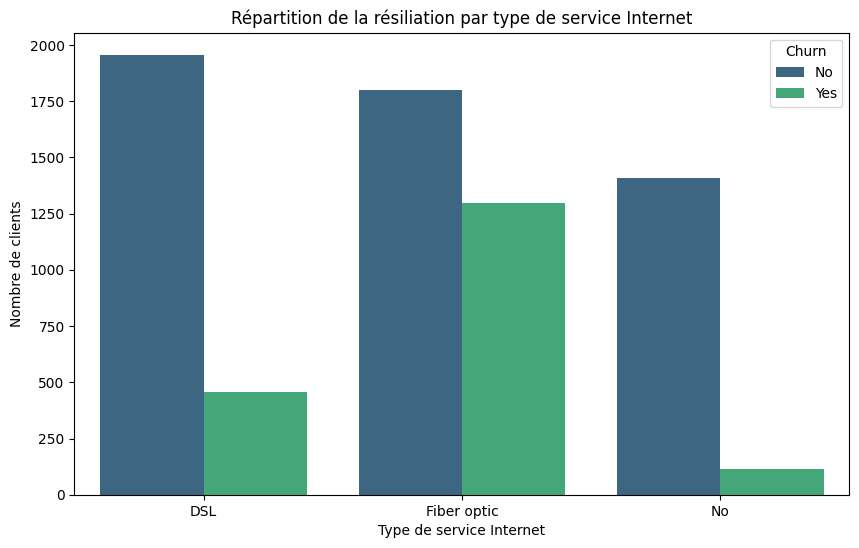

In [63]:
plt.figure(figsize=(10, 6))
# On crée un graphique à barres montrant le nombre de clients par service, coloré par Churn
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')

plt.title('Répartition de la résiliation par type de service Internet')
plt.xlabel('Type de service Internet')
plt.ylabel('Nombre de clients')
plt.show()

Interprétation :    

- On peut voir que la proportion de personnes qui résilient leur abonnement DSL est bien moins élevée que celles de personnes qui le maintiennent

- On peut également voir que pour ce qui est de la fibre optique, la proportion de personnes résiliant leurs abonnement est presque identique à celle des personnes le maintenant, ce qui peut faire se poser des questions sur la satisfaction des clients quant aux services de fibre optique, d'un point de vue global.

- No : cette colonne signifie qu'ils ne fournissent pas de services. Cela s'applique aux personnes ne prenant pas de service internet, et représentent tout le reste des clients (les clients ne prenant qu'un service téléphonique par exemple seront représenté ici), on voit que les personnes qui ne prennent pas de services internet ont bien moins tendance à se dasabonner de nos services.

Ainsi, on peut en déduire que la majorité du temps les services se faisant résilier sont des services en rapport avec internet. Cela peut nous amener à nous poser des questions quant à la satisfaction de nos services internet ou d'autres facteurs tel que leur prix, etc. Tandis que cela peut nous conforter dans l'idée que nos services hors internet satisfont globalement nos clients.

#Hypothèses

Selon les différentes obser ations que nous avons faites, nous pouvez émettre quelques hypothèses, qui seront utiles avant de passer aux étapes de modélisation :    

- Hypothèse 1 - Une vulnérabilité au niveau des nouveux clients :    
Les observations que nous avons eu tendent à montrer une certaine vulnérabilité des nouveaux clients qui semblent plus à même de résilier nos services. Nous pouvons ob server que la majorité de nos clients tendent à quitter notre enteprise dans les premiers mois et sont souvent des personnes ayant des abonnements de type month-to-month. A l'inverse, les contrats plus long (d'un an ou deux ans) ainsi que l'ancienneté du client semblent les fidéliser davantage.

- Hyphothèse 2 - Problème notre offre de ficbre optique :    
Tout comme l'un de nos graphiques précédents le montrait, parmi tous les services que nous proposons, l'un semble davantage entraîner des désabonnements que tous les autres services proposés par notre entreprise. Cela pourrait indiquer un problème de qualité de notre service ou un désavantage face à la conccurence proposant des services similaires.

- Hyphothèse 3 - Existance de deux tendances tarifaires distinctes :    
On peut voir qu'une très grande portion des abonnés ont tendance à dépenser de petites sommes, tandis qu'une autre grande partie a tedance à dépense des sommes plus élevées sans qu'il n'y ait un pic de concentration des clients pour l'un de ces différentes sommes élevées. Ce qu'il serait intéressant de jauger, serait la possible existence d'une corrélation entre lee désabonnements, en fonctio du prix payé par les abonnés.

### EDA-6 - Nettoyage et préprocessing

Son but est simple : transformer un fichier texte lisible par un humain en un tableau mathématique compréhensible par une machine.

In [64]:

# On rempllace "Yes" et "No" de Churn par 0 ou 1, le machine learning se fait via des valeurs numérioques
df['Churn'] = df['Churn'].map({'No':0 ,'Yes': 1}).astype('category')

Pour valider scientifiquement la pertinence de nos variables catégorielles par rapport à la cible (Churn), nous utilisons deux indicateurs complémentaires.

# A. Le Test du Chi-deux (χ²) :

Ce premier test c'est le test d'indépendance statistique. En gros, ça nous permet de savoir si la distribution d'une de nos variables (comme par exmple le type de contrat) a un vrai lien avec la cible. Pour ça on regarde l'indicateur de la p-value. Si on voit que la p-value est en dessous de 0.05, on condidère que le lien est significatif, donc qu'on a 95% de certitude que la variable a une influence sur les désabonnements et que c'est pas juste du au hazard. Par contre si c'est au dessus de 0.05, on peut rien prouver du tout et on en deduit que la variable n'influence pas le Churn.

# B. Le V de Cramér : "Le lien est-il puissant ?"

Ensuite, une fois qu'on a pu confirmer qu'il y a bien un lien grace au test du Chi-deux, on utilise le V de Cramér pour mesurer a quel point cette relation est forte. C'est un indicateur qui se mesure sur une échelle de 0 à 1. Pour l'interpréter c'est assez simple : si le score est entre 0.00 et 0.10 c'est que le lien est vraiemnt très faible, voir négligeable. Si on est entre 0.10 et 0.30 on est sur un lien modéré. Et enfin si on obient un résultat supérieur à 0.30, ça montre un lien fort et du coup ça correspond à nos variables prédictives les plus importantes pour la suite.

In [65]:
import scipy.stats as stats
import pandas as pd
import numpy as np

def analyse_cramer(colonne_etudiee, cible='Churn'):
    #On crée la table de contingence
    confusion_matrix = pd.crosstab(df[colonne_etudiee], df[cible])

    #SECURITE : Si la table est vide ou na qu'1 seule ligne/colonne, le test chi2 est pas possible
    if confusion_matrix.size == 0 or confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        print(f"--- {colonne_etudiee} --- : Analyse impossible (données insuffisantes ou colonne vide)\n")
        return

    #Calcul du Chi2
    chi2, p, dof, ex = stats.chi2_contingency(confusion_matrix)

    #Calcul du V de Cramer
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * min_dim))

    print(f"--- {colonne_etudiee} vs {cible} ---")
    print(f"p-value (Chi²) : {p:.5f}")
    print(f"V de Cramér : {v_cramer:.5f}\n")

#1) On identifie les colonnes catégorielles présentes dans le DF actuel
colonnes_cat = df.select_dtypes(include=['object', 'category']).columns

#2) On exclut Churn et on s'assure que les colonnes existent bien
colonnes_a_tester = [col for col in colonnes_cat if col != 'Churn']

print(f"Lancement de l'analyse pour {len(colonnes_a_tester)} variables :\n")

#3) Boucle securise
for col in colonnes_a_tester:
    try:
        analyse_cramer(col)
    except Exception as e:
        print(f"Erreur sur la colonne {col}: {e}")

Lancement de l'analyse pour 17 variables :

--- customerID vs Churn ---
p-value (Chi²) : 0.49439
V de Cramér : 1.00000

--- gender vs Churn ---
p-value (Chi²) : 0.49049
V de Cramér : 0.00822

--- SeniorCitizen vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.15010

--- Partner vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.14966

--- Dependents vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.16278

--- PhoneService vs Churn ---
p-value (Chi²) : 0.34992
V de Cramér : 0.01115

--- MultipleLines vs Churn ---
p-value (Chi²) : 0.00357
V de Cramér : 0.04004

--- InternetService vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.32191

--- OnlineSecurity vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.34699

--- OnlineBackup vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.29190

--- DeviceProtection vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.28116

--- TechSupport vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.34251

--- StreamingTV vs Churn 

#  Analyse des variables et recommandations de nettoyage

| Variable           | p-value (Chi²) | V de Cramér | Probabilité de suppression | Commentaire |
|-------------------|----------------|-------------|----------------------------|------------|
| customerID        | 0.49439        | 1.00000     | Très élevée                | Identifiant unique, inutile pour prédiction |
| gender            | 0.49049        | 0.00822     | Élevée                     | Pas de lien significatif avec le Churn |
| SeniorCitizen     | 0.00000        | 0.15010     | Faible                     | Lien faible mais significatif |
| Partner           | 0.00000        | 0.14966     | Faible                     | Lien faible mais significatif |
| Dependents        | 0.00000        | 0.16278     | Faible                     | Lien faible à modéré |
| PhoneService      | 0.34992        | 0.01115     | Élevée                     | Pas de lien significatif |
| MultipleLines     | 0.00357        | 0.04004     | Moyenne                     | Lien très faible |
| InternetService   | 0.00000        | 0.32191     | Faible                     | Lien fort, conserver |
| OnlineSecurity    | 0.00000        | 0.34699     | Faible                     | Lien fort, conserver |
| OnlineBackup      | 0.00000        | 0.29190     | Faible                     | Lien modéré à fort, conserver |
| DeviceProtection  | 0.00000        | 0.28116     | Faible                     | Lien modéré à fort, conserver |
| TechSupport       | 0.00000        | 0.34251     | Faible                     | Lien fort, conserver |
| StreamingTV       | 0.00000        | 0.23014     | Moyenne                     | Lien modéré, à évaluer |
| StreamingMovies   | 0.00000        | 0.23070     | Moyenne                     | Lien modéré, à évaluer |
| Contract          | 0.00000        | 0.40956     | Très faible                 | Facteur clé, à conserver absolument |
| PaperlessBilling  | 0.00000        | 0.19113     | Moyenne                     | Lien modéré, à évaluer selon modèle |
| PaymentMethod     | 0.00000        | 0.30296     | Faible                     | Lien fort, conserver |

# Justification des suppressions (Cleaning)

Sur la base de l'analyse automatisée des 17 variables, nous recommandons le nettoyage suivant :

---

## Colonnes à supprimer systématiquement

| Colonne       | Motif de suppression                                                                 | Preuve Statistique |
|---------------|--------------------------------------------------------------------------------------|------------------|
| customerID    | Identifiant unique, chaque ID est lié à une seule ligne, inutile pour la prédiction. | V = 1.000        |
| gender        | Aucune différence statistique de comportement entre les hommes et les femmes.       | p-value = 0.490  |
| PhoneService  | L'accès au service téléphonique n'influence pas significativement la décision de résilier. | p-value = 0.350  |

---

## Colonnes à conserver absolument

Ces variables présentent un lien fort ou très fort avec le Churn et sont critiques pour la performance du modèle :

| Colonne           | V de Cramér | Commentaire |
|-------------------|-------------|------------|
| Contract          | 0.40956     | Facteur clé, type d'engagement |
| OnlineSecurity    | 0.34699     | Forte influence, assistance technique |
| TechSupport       | 0.34251     | Forte influence, assistance technique |
| InternetService   | 0.32191     | Technologie (Fibre vs DSL) impacte la satisfaction |
| PaymentMethod     | 0.30296     | Influence notable sur le Churn |
| OnlineBackup      | 0.29190     | Lien modéré à fort, important à conserver |
| DeviceProtection  | 0.28116     | Lien modéré à fort, important à conserver |

---

## Colonnes à supprimer **si nécessaire** (simplification du modèle)

Ces variables ont un lien faible ou modéré et peuvent être retirées si le modèle doit être simplifié ou si elles génèrent de la redondance :

| Colonne           | V de Cramér | Commentaire |
|-------------------|-------------|------------|
| SeniorCitizen     | 0.15010     | Lien faible mais significatif |
| Partner           | 0.14966     | Lien faible mais significatif |
| Dependents        | 0.16278     | Lien faible à modéré |
| MultipleLines     | 0.04004     | Lien très faible |
| StreamingTV       | 0.23014     | Lien modéré |
| StreamingMovies   | 0.23070     | Lien modéré |
| PaperlessBilling  | 0.19113     | Lien modéré, à évaluer selon modèle |

In [66]:
cols_to_drop = ['customerID', 'gender', 'PhoneService']
df.drop(columns=cols_to_drop, inplace=True)


# Analyse des Corrélations (Variables Numériques)

Alors que le Chi-deux mesure l'indépendance entre catégories, la Corrélation de Pearson mesure la force et la direction du lien linéaire entre deux variables chiffrées. Le coefficient $r$ varie de -1 à +1.

---

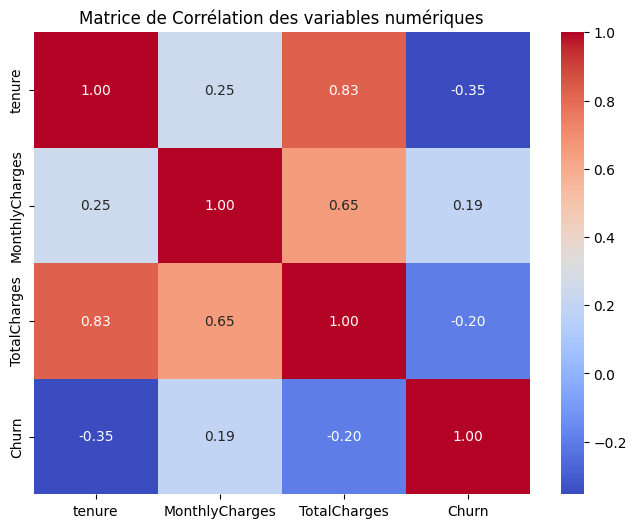

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

#Selection des colonnes numeriques uniquement
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df[num_cols].corr()

# Affichage de la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des variables numériques')
plt.show()



## 1. Interprétation de la Heatmap

D'après les résultats affichés sur la matrice de corrélation :

| Lien analysé           | Coefficient (r) | Interprétation |
|------------------------|----------------|----------------|
| tenure vs Churn         | -0.35          | Forte corrélation négative. Plus l'ancienneté augmente, plus la probabilité de départ diminue (les clients anciens sont plus fidèles). |
| MonthlyCharges vs Churn | +0.19          | Corrélation positive faible. Les clients avec des factures mensuelles élevées ont une tendance légèrement plus forte à résilier. |
| TotalCharges vs Churn   | -0.20          | Corrélation négative faible. Ce lien est trompeur car il est fortement influencé par l'ancienneté. |

---

## 2. Détection de la redondance (=Multicolinéarité)

Un point crucial est la relation entre les variables explicatives elles-mêmes :

tenure vs TotalCharges (r = 0.83) : il y a une très fore corrélation entre les deux. Au nvieau métier c'est en fait trsè logique: plus un client reste chez nous longtemps (=tenure), plus l'addition de toutes ses factures (TotalCharges) va forcement être élevée. Le soucis c'est que si on décide de garder les deux variables dans notre modèle de Machine Learning, ça risque de faire doublon et de créer de la redondance.

---

## 3. Conclusion pour le Nettoyage

Du coup, suite a cette analyse on a fait nos choix pour les prochaines étapes :

- On a décidé de garder tenure et MonthlyCharges parcque c'est vraiment nos deux signaux les plus "propres" pour esayer de prédire les désabonnements.

- On va faire attention avec TotalCharges : vu que c'est hyper redondant avec l'ancienneté (corrélétion à 83%), on l'enlèvera surement si on voit que notre modèle final est instable. Ca permetra de simplifier l'algoritme.

---

### Résumé pour évaluation

En bref, grace a l'analyse par corélation de Pearson on a pu confirmer que l'ancienneté c'est vraiment le facteur principal qui retient les clients (r= -0.35). Et on a aussi vu une grosse redondance entre tenure et TotalCharges (r=0.83) donc eon  pourrait être ammener a simplifier nos données pendant la phase d'entrainement du modèle.

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   category
 1   Partner           7032 non-null   category
 2   Dependents        7032 non-null   category
 3   tenure            7032 non-null   int64   
 4   MultipleLines     7032 non-null   category
 5   InternetService   7032 non-null   category
 6   OnlineSecurity    7032 non-null   category
 7   OnlineBackup      7032 non-null   category
 8   DeviceProtection  7032 non-null   category
 9   TechSupport       7032 non-null   category
 10  StreamingTV       7032 non-null   category
 11  StreamingMovies   7032 non-null   category
 12  Contract          7032 non-null   category
 13  PaperlessBilling  7032 non-null   category
 14  PaymentMethod     7032 non-null   category
 15  MonthlyCharges    7032 non-null   float64 
 16  TotalCharges      7032 non-nu

### Encodage binaire pour les colonnes avec exactement 2 valeurs uniques

Le grand but de cette étape c'est d'arriver a transformer nos colonnes catégorielles binaires en un format numérique que nos algorithmes de Machine Learning pourront vraiment exploiter. Pour commencer, on a décidé d'afficher toutes les valeurq uniques présentes dans chaque colonne de type category pour bien voir ce qu'on avait.

---

### Identifier les colonnes binaires

Ensuite, on a ciblé uniquement les colonnes qui on exactement 2 valeurs uniques (comme par exemple Yes/No, Male/Female...). Evidemment on ignore completement les colonnes qui sont déja numériques de base (les trucs en int ou float). Une fois qu'on a bien isolé nos colonnes catégorielles "binaires", on les tranforme directement en format Int64.

In [69]:
for col in df.select_dtypes(include=['category']).columns:
    print(f"--- Colonne : {col} ---")
    print(f"Nombre de catégories : {df[col].nunique()}")
    print(f"Valeurs : {df[col].unique().tolist()}")
    print()

--- Colonne : SeniorCitizen ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']

--- Colonne : Partner ---
Nombre de catégories : 2
Valeurs : ['Yes', 'No']

--- Colonne : Dependents ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']

--- Colonne : MultipleLines ---
Nombre de catégories : 3
Valeurs : ['No phone service', 'No', 'Yes']

--- Colonne : InternetService ---
Nombre de catégories : 3
Valeurs : ['DSL', 'Fiber optic', 'No']

--- Colonne : OnlineSecurity ---
Nombre de catégories : 3
Valeurs : ['No', 'Yes', 'No internet service']

--- Colonne : OnlineBackup ---
Nombre de catégories : 3
Valeurs : ['Yes', 'No', 'No internet service']

--- Colonne : DeviceProtection ---
Nombre de catégories : 3
Valeurs : ['No', 'Yes', 'No internet service']

--- Colonne : TechSupport ---
Nombre de catégories : 3
Valeurs : ['No', 'Yes', 'No internet service']

--- Colonne : StreamingTV ---
Nombre de catégories : 3
Valeurs : ['No', 'Yes', 'No internet service']

--- Colonne : StreamingMovies ---
Nomb

### Encodage binaire pour les colonnes avec exactement 3 valeurs uniques de type "Yes" , "No", "No internet service"

- En regardant de plus près, on c'est rendu compte qu'il y a certaines colonnes qui on 3 valeurs au lieu de 2 : "Yes", "No", et un troisième option du genre "No internet service" ou "No phone service".

- En fait, on peux facilement simplifier ces colonnes. Logiquement, dire qu'un client n'a "pas de service internet", ça revient exactement à dire "No" pour cette option. Du coup, on a pris la decison de remplacer tout les 'No internet service' (et pareil pour la colonne du téléphone) directement par un simple "No".

- Grâce a cette manip, nos colonnes redeviennent purement binaires et on a plus qu'a appliquer exactement la même logique d'encodage qu'on a vu juste au dessus

In [70]:
# Apres avoir parcouru ses colonnes, on remarque que les colonnes ont des valeurs de type ["Yes", "No", "No internet service"]
# On remplace "No internet service" ou "No phone service"
cols_a_simplifier = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'MultipleLines',
                     'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_a_simplifier:
    if col in df.columns:
        #On remplace 'No internet service' par 'No'
        df[col] = df[col].replace(to_replace=r'^No .+$', value='No', regex=True)
        print(f"--- Colonne : {col} ---")
        print(f"Nombre de catégories : {df[col].nunique()}")
        print(f"Valeurs : {df[col].unique().tolist()}")
print("Simplification terminée avec Regex.")

--- Colonne : OnlineSecurity ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : OnlineBackup ---
Nombre de catégories : 2
Valeurs : ['Yes', 'No']
--- Colonne : DeviceProtection ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : MultipleLines ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : TechSupport ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : StreamingTV ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : StreamingMovies ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
Simplification terminée avec Regex.


In [71]:
#1. Identifier les colonnes avec exactement 2 valeurs uniques
#On exclut les colonnes déjà numériques (float/int) pour ne cibler que le texte/catégories
colonnes_binaires = [col for col in df.columns if df[col].nunique() == 2]

print(f"Colonnes binaires détectées : {colonnes_binaires}")

#2. Application de l'encodage binaire (0 et 1)
for col in colonnes_binaires:
    # On recup les deux valeurs (ex: 'No', 'Yes')
    valeurs = df[col].unique()
    print(f"Encodage de {col} : {valeurs[0]} -> 0, {valeurs[1]} -> 1")
    # Transformation
    df[col] = df[col].map({valeurs[0]: 0, valeurs[1]: 1})
    df[col] = df[col].astype("Int64")

#3. verif du résultat
print("\n--- Verification des types après encodage")
print(df[colonnes_binaires].dtypes)
df.head()
df.info()

df["Churn"].value_counts()

Colonnes binaires détectées : ['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
Encodage de SeniorCitizen : No -> 0, Yes -> 1
Encodage de Partner : Yes -> 0, No -> 1
Encodage de Dependents : No -> 0, Yes -> 1
Encodage de MultipleLines : No -> 0, Yes -> 1
Encodage de OnlineSecurity : No -> 0, Yes -> 1
Encodage de OnlineBackup : Yes -> 0, No -> 1
Encodage de DeviceProtection : No -> 0, Yes -> 1
Encodage de TechSupport : No -> 0, Yes -> 1
Encodage de StreamingTV : No -> 0, Yes -> 1
Encodage de StreamingMovies : No -> 0, Yes -> 1
Encodage de PaperlessBilling : Yes -> 0, No -> 1
Encodage de Churn : 0 -> 0, 1 -> 1

--- Verification des types après encodage
SeniorCitizen       Int64
Partner             Int64
Dependents          Int64
MultipleLines       Int64
OnlineSecurity      Int64
OnlineBackup        Int64
DeviceProtection    Int64
TechSupport      

,count
Churn,
0,5163
1,1869


#  Encodage et standardisation des données

Pour préparer les données au Machine Learning, nous appliquons trois transformations simples :

- RobustScaler : nosu permet de normaliser toutes nos variables numériques pour qu'elles soient bien sur la meme échelle. Ça évite qu'une variable avec des grands nombres prenne le dessus sur les autres dans le modèle

- Ordinal Encoding : pour transformer nos variables catégorielles qui on un vrai ordre logique en des valeurs numeriques (pour que l'algo comprenne la hiérarchie)

- One-Hot Encoding : c'est pour les catégories ou y a pas du tout d'ordre particulier. Ca nous les transforme direct en plein de petites colonnes binaires

---

##  Méthodes utilisées

| Type de colonne | Colonnes Telco | Méthode | Pourquoi ? |
|-----------------|---------------|--------|------------|
| Numériques | tenure, MonthlyCharges, TotalCharges | RobustScaler | Met les variables sur la même échelle pour améliorer les performances du modèle |
| Ordinale | Contract,  InternetService,| Ordinal Encoding | Il existe un ordre : Mensuel < 1 an < 2 ans, De même pour le type d'internet : No < ADSL < Fibre |
| Nominale | PaymentMethod | One-Hot Encoding | Pas d'ordre entre ses catégories |

---

## Objectif

Obtenir un dataset propre, numérique et équilibré pour entraîner efficacement les modèles de ML

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

cols_numeriques = ['tenure', 'MonthlyCharges']
cols_numeriques_log = ['TotalCharges'] #forte asymetrie (skewness = 0.96)
cols_ordinales = ['Contract','InternetService']
cols_nominales = ['PaymentMethod']

categories_contract = ['Two year', 'One year', 'Month-to-month']
categories_InternetService = ['No','DSL','Fiber optic']


# 2. creation d'un mini-pipeline specifique pour totalcharges skewness = 0.96
log_scale_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, validate=False)), # 1) redresse la courbe
    ('scaler', RobustScaler())                            # 2) msie à l'echelle
])

preprocessor = ColumnTransformer(
    transformers=[
        #standardisation des valeurs numériques continues
        ('num', RobustScaler(), cols_numeriques),
       #numériques avec correction d'asymétrie (totalcharges)
        ('num_log', log_scale_transformer, cols_numeriques_log),
        # encodage ordinal pour le contrat
        ('ord', OrdinalEncoder(categories=[categories_contract,categories_InternetService]), cols_ordinales),
        #encodage One-Hot pour les variables nominales
        ('nom', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cols_nominales)
    ],
    # Les colonnes binaires (0/1) ne sont pas dans les listes ci-dessus.
    # remainder='passthrough' permet de les garder telles quelles
    remainder='passthrough'
)

preprocessor.set_output(transform="pandas")



ColumnTransformer(remainder='passthrough',
                  transformers=[('num', RobustScaler(),
                                 ['tenure', 'MonthlyCharges']),
                                ('num_log',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', RobustScaler())]),
                                 ['TotalCharges']),
                                ('ord',
                                 OrdinalEncoder(categories=[['Two year',
                                                             'One year',
                                                             'Month-to-month'],
                                                            ['No', 'DSL',
                                                             'Fiber optic']]),
                                 ['Contract', 'InternetService']),
                                ('nom',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['PaymentMethod'])])

In [73]:
print("--- Prepa pour le Machine Learning")

# 1. Séparation de la cible (y) et des caractéristiques (X)
# Assure-toi que la colonne s'appelle bien 'Churn', sinon adapte le nom
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Découpage en Train (80%) et Test (20%)
# stratify=y est crucial ici : il garantit qu'il y aura le même pourcentage de désabonnements dans le train et le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Application du preprocessor (La règle d'or anti-triche !)
# On utilise fit_transform SUR LE TRAIN pour que le RobustScaler apprenne les médianes
X_train_final = preprocessor.fit_transform(X_train)

# On utilise UNIQUEMENT transform SUR LE TEST (le modèle découvre ces données, il ne doit pas s'en servir pour ajuster le scaler)
X_test_final = preprocessor.transform(X_test)

print("Dimensions X_train :", X_train_final.shape)
print("Dimensions X_test  :", X_test_final.shape)
print("Dimensions y_train :", y_train.shape)

--- Prepa pour le Machine Learning
Dimensions X_train : (5625, 20)
Dimensions X_test  : (1407, 20)
Dimensions y_train : (5625,)


In [74]:
print(df.columns.tolist())
print("\n----------Information du dataframe df")
print("colonnes du df avant Encoding :",df.columns.tolist())

df.info()
print("\n\n")

print("---------- Information du dataframe d'entraînement (X_train_final)")
print("Colones après Encoding :", X_train_final.columns.tolist())
X_train_final.info()



['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

----------Information du dataframe df
colonnes du df avant Encoding : ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   Int64   
 1   Partner           7032 non-null   Int64   
 2   Dependents        7032 non-null   Int64   
 3   tenure        

# Préparation finale des données pour le Machine Learning

Cette étape a converti notre base de données brute en une matrice numérique saine, prête pour l'apprentissage de l'algorithme :

- Nettoyage des variables (Regex) : On a décidé de regrouper les valeurs comme "No internet service" ou "No phone service" avec les "No" classiques. Ca permet de simplifier le dataset et surtout d'eviter des problèmes de multicolinéarité par la suite.

- Encodage adapté : Pour les statuts simples on a opté pour une binarisation manuelle (0/1). Ensuite, on a utilisé un OrdinalEncoder pour bien respecter la hiérarchie de la variable Contract, et un OneHotEncoder pour les catégories restantes (comme PaymentMethod et InternetService).

- Correction financière :En regardant la variable TotalCharges, on a remarqué une forte asymétrie (Skewness = 0.96). Pour corriger ca, on a mis en place un pipeline dédié (np.log1p + RobustScaler), ce qui permet de normaliser la distribution et de protéger notre modèle des montants extrèmes

- Zéro fuite de données (Data Leakage) :On a fait attention a bien isoler la cible (Churn) en amont. Notre jeu de test (stratifié à 20%) n'a subit qu'une méthode .transform(), ce qui empeche totalement ses données de venir polluer la phase d'entrainement.

---

###Bilan :
Nos matrices X_train_final et X_test_final sont desormais standardisées, numérisées et sans biais asymétrique.
Le terrain est techniquement pret pour passer à la modélisation.

#Modélisation

Au sein de cette partie nous allons faire les modélisation, dans un premier temps nous allons faire des algorithmes d'apprentisage supervisé, et procéderont enfin à des algorithmes d'apprentissage non supervisés.

#Apprentissage supervisé :    

In [75]:
# --- IMPORTATIONS POUR LA MODELISATION ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


#------MODELE 1 : RÉGRESSION LOGISTIQUE

print("--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE ---")

#1) Création de l'algorithme
logreg = LogisticRegression(max_iter=1000, random_state=42)

# 2) Entraînement sur les données préparées par la partie 3
logreg.fit(X_train_final, y_train)

#3) Prédictions sur les données de test
y_pred_logreg = logreg.predict(X_test_final)

# 4. Évaluation
print(classification_report(y_test, y_pred_logreg))

#------MODÈLE 2 : RANDOM FOREST

print("\n--- 2. MODÈLE RANDOM FOREST (Forêt Aléatoire) ---")

#1) Création de l'algorithme
rf = RandomForestClassifier(random_state=42)

# 2) Entrainement
rf.fit(X_train_final, y_train)

#3. Prédictions
y_pred_rf = rf.predict(X_test_final)

# 4. Évaluation
print(classification_report(y_test, y_pred_rf))

from sklearn.neighbors import KNeighborsClassifier

#------MODÈLE 3 : K-NEAREST NEIGHBORS (KNN)

print("\n--- 3. MODELE K-NEAREST NEIGHBORS (KNN)")

# 1. Création de l'algorithme (on cherche les 5 clients les plus similaires)
knn_opti = KNeighborsClassifier(n_neighbors=5)

# 2. Entraînement sur les mêmes données que les autres modèles !
knn_opti.fit(X_train_final, y_train)

# 3. Prédictions
y_pred_knn = knn_opti.predict(X_test_final)

# 4. Evaluation
print(classification_report(y_test, y_pred_knn))

--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1033
         1.0       0.65      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


--- 2. MODÈLE RANDOM FOREST (Forêt Aléatoire) ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1033
         1.0       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407


--- 3. MODELE K-NEAREST NEIGHBORS (KNN)
              precision    recall  f1-score   support

         0.0       0.83      0.85      0.84      1033
         1.0       0.55      0.52      0.54       374

    accuracy                           0.76    

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   Int64   
 1   Partner           7032 non-null   Int64   
 2   Dependents        7032 non-null   Int64   
 3   tenure            7032 non-null   int64   
 4   MultipleLines     7032 non-null   Int64   
 5   InternetService   7032 non-null   category
 6   OnlineSecurity    7032 non-null   Int64   
 7   OnlineBackup      7032 non-null   Int64   
 8   DeviceProtection  7032 non-null   Int64   
 9   TechSupport       7032 non-null   Int64   
 10  StreamingTV       7032 non-null   Int64   
 11  StreamingMovies   7032 non-null   Int64   
 12  Contract          7032 non-null   category
 13  PaperlessBilling  7032 non-null   Int64   
 14  PaymentMethod     7032 non-null   category
 15  MonthlyCharges    7032 non-null   float64 
 16  TotalCharges      7032 non-nu

In [77]:
# --- OPTIMISATION : ENTRAINEMENT SANS CERTAINES COLONNES ---
print("\n--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE OPTIMISÉ ---")

# 1. Définir la liste des colonnes à enlever (à adapter avec tes vrais noms de colonnes)
colonnes_en_trop = ['TotalCharges','SeniorCitizen','Partner','MultipleLines','Dependents','StreamingTV','PaperlessBilling'] # Remplace par tes choix !

# 2. Créer les nouveaux jeux de données allégés
X_train_opti = X_train_final.drop(columns=colonnes_en_trop, errors='ignore')
X_test_opti = X_test_final.drop(columns=colonnes_en_trop, errors='ignore')

# 3. Création et entraînement du NOUVEAU modèle
logreg_opti = LogisticRegression(max_iter=1000, random_state=42)
logreg_opti.fit(X_train_opti, y_train)

# 4. Prédictions et Évaluation
y_pred_opti = logreg_opti.predict(X_test_opti)
print(classification_report(y_test, y_pred_opti))



#------ MODÈLE 2 : RANDOM FOREST

print("\n--- 2. MODÈLE RANDOM FOREST (Forêt Aléatoire) ---")

# 1. Création de l'algorithme
rf = RandomForestClassifier(random_state=42)

# 2. Entraînement
rf.fit(X_train_final, y_train)

# 3. Prédictions
y_pred_rf = rf.predict(X_test_final)

# 4. Evaluation
print(classification_report(y_test, y_pred_rf))



#------MODELE 3 : K-NEAREST NEIGHBORS (KNN)

print("\n--- 3. MODÈLE K-NEAREST NEIGHBORS (KNN)  ---")

# 1. Création de l'algorithme (on cherche les 5 clients les plus similaires)
knn_opti = KNeighborsClassifier(n_neighbors=5)

# 2. Entraînement sur les données allégées
knn_opti.fit(X_train_opti, y_train)

# 3. Prédictions
y_pred_knn = knn_opti.predict(X_test_opti)

# 4. Évaluation
print(classification_report(y_test, y_pred_knn))



--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE OPTIMISÉ ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1033
         1.0       0.65      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


--- 2. MODÈLE RANDOM FOREST (Forêt Aléatoire) ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1033
         1.0       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407


--- 3. MODÈLE K-NEAREST NEIGHBORS (KNN)  ---
              precision    recall  f1-score   support

         0.0       0.83      0.85      0.84      1033
         1.0       0.55      0.52      0.54       374

    accuracy                    

Explications :

####Méthodes utilisées :
- Nous avons entraîné un premier modèle avec toutes les données disponiblesafin d'avoir un point de repère. Ensuite, nous avons testé un modèle allégé en supprimant 7 colonnes qui nous semblaient inutiles.

- En comparant les deux, nous avons vu que les scores (Recall, Accuracy et F1-score) restaient exactement les mêmes, confirmant que ces 7 colonnes n'apportaient aucune information utile pour prédire le Churn. Ona docn gardé un modele allégé puisqu'il vaut mieux simpleiefer notre modele si on peut le faire :notre modele sera plus performant au moment de tourner et aura moins de "bruit".

####Choix des algorithmes de modélisation :
Afin de pouvoir comparer les performances de plusieurs algorithmes et d'avoir une meilleure visibilité sur le modèle à préferer parmis tous ceux que l'on a envisagé, nous avons effectuer 3 modélisations avec trois modèles distincts. Nous allons justifier le choix de chacun d'entre eux ci-dessous aisi que celui que nous allons choisir et pourquoi :

####Explication de chaque algorithmes :
- La Régression Logistique : Elle calcule des probabilités. C'est notre modèle de base, simple et direct.

- Le Random Forest : C'est une méthode basée sur des arbres de décision (il pose plein de questions 'oui/non' successives).

- Le KNN (K-Plus Proches Voisins) : C'est une méthode basée sur la "distance". Il regarde quels sont les 5 clients qui ressemblent le plus à notre client cible pour deviner ce qu'il va faire selon ce que ces clients ont fait.

####Métriques d'évaluation :
La fonction "classification_report" nous permet d'avoir des métriques d'évaluation de notre modèle. Voici quelles sont nos métriques et ce qu'elles signifient :

- Accuracy : Pourcentage de réponses ui ont ien été devinées par la modèle, cela peut être trompeur s'il y a plus de clients qui reste que de clients qui s'en vont

- Recall : permet de détecter parmi tous les clients qui ont réellement résilié, combien notre modèle a réussit à réellement trouver. Nous sohaitons avoir un bon recall, signifiant moins de risque d'avoir raté un client qui est réellement partie, mais la métrique suivante nous intéresse davantage.

- F1-Score : Il s'agit d'un compromis entre le calcul de précision et recall, en ne se focalisant pas uniquement sur le recall, ça permet d'avoir une vue d'ensemble sur le modèle pas juste sur un calcul du recall

- Precision : Cela nous permet de savoir parmi les positifs prédits, combien sont correctes.

#Essai avec un autre modélèle d'apprentissage supervisé :

In [78]:
import xgboost as xgb
from sklearn.metrics import classification_report

print("--- ENTRAINEMENT DU MODELE XGBOOST (VERSION OPTIMISE) ---")

# 1. Calcul du ratio pour équilibrer les classes
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# 2. Création du modèle avec les réglages optimaux
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_final, y_train)

# 4. Prédictions et evaluation
y_pred_xgb = xgb_model.predict(X_test_final)

print("\n--- RESULTATS ---")
print(classification_report(y_test, y_pred_xgb))

--- ENTRAINEMENT DU MODELE XGBOOST (VERSION OPTIMISE) ---

--- RESULTATS ---
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1033
         1.0       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



#Explications :    



# Explications : Notre modèle XGBoost

## 1. Comment ça marche :    

XGBoost est un algorithme qui va créer plein de petits modèles (ici une centaine d'arbres de décision) les uns à la suite des autres. C'est intressant car chaque nouveau modèle va se concentrer uniquement sur les erreurs qu'a fait le modèle précedent pour essayer de les corriger. A la fin, en combinant tout ça, on obtient un algorithme global vraiment robuste et très précis.

Exemple étape par étape :    

- Le premier fait une prédiction.
- Le deuxième corrige uniquement les erreurs du premier.
- Le troisième corrige les erreurs du deuxième.
- (Et ainsi de suite...)

À la fin, on obtient un super-expert qui est capacle de faire des prédictions très précises.

---

## 2. Ses Critères (Ce qu'il cible)

###Contrat (son critère n°1)
Le contrat : C'est le critère numéro 1. Les clients qui on un abonnement "Month-to-month" (mois par mois) representent le plus gros risque de désabonnement.

###Internet (Critère n°2)
Le fait d'avoir la Fibre Optique aggrave le risque, surement parce que ce sont des abonnements qui coutent plus cher et où les pannes agacent le plus les clietns

###Ancienneté / Prix
Ce sont plutôt des critères secondaires qui vont aider l'algorithme a trancher quand il hesite.


## 3. Ses Performances

### Recall = 80%
Le modèle détecte presque tous les clients qui vont réellement résilier.

---

### Les fausses alertes (Précision = 52%)

C'est la contrepartie, on a pas mal de "fausses alertes" : ça veut dire que sur 100 clients que le modele signale comme risqués, y en a 52 qui vont vraiment partir, et 48 qui comptaient finalement rester.

### Pourquoi c'est idéal en entreprise ?

On pourrait penser que les fausses alertes sont un problème,mas dans notre contexte d'entrepeise ce n'est pas grave , au contraire : en terme de couts  envoyer un e-mail promotionnel ou proposer une petite remise pour retenir un client ça ne coute quasiment rien.
Pour le service marketing, il est largement préferable d'avoir un algo qui fait du "sur-ciblage" plutot qu'un algorithme qui raterait des départs. Mieux vaut prévenir 100 clients (et en sauver 52) quitte a donner des petites promos a des gens qui restaient, plutot que de perdre des clients importants a cause d'un modèle trop frileux.

#Apprentissage non supervisé :

APPRENTISSAGE NON SUPERVISÉ (CLUSTERING)


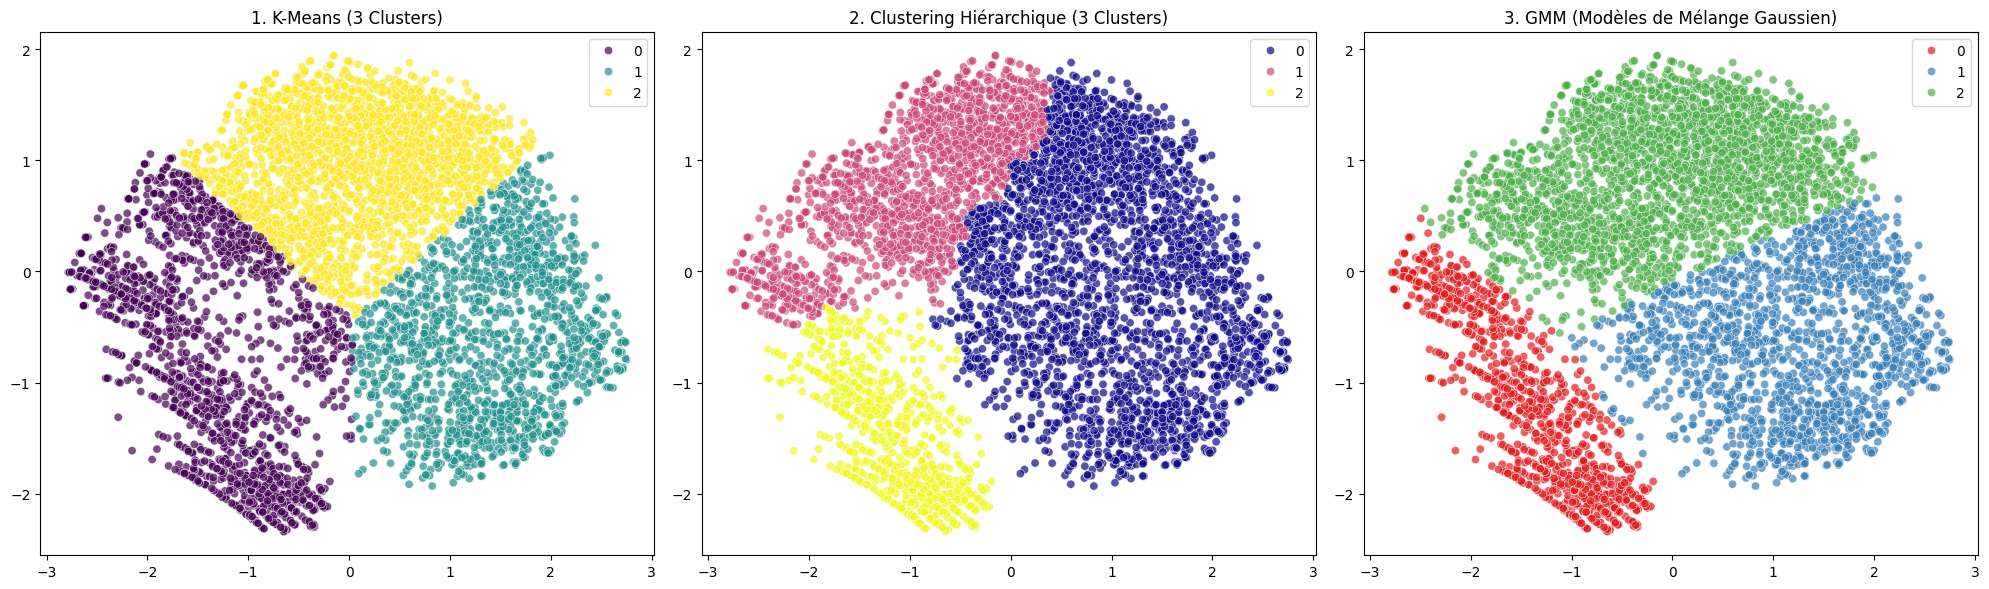

In [79]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("APPRENTISSAGE NON SUPERVISÉ (CLUSTERING)")

# --- REDUC DE DIMENSION (PCA)
# On compresse nos données en 2 axes pour pouvoir les visualiser sur un graphique 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_final)


# ---MODELE 1 : K-MEANS
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_kmeans = kmeans.fit_predict(X_pca)

# ---MODELE 2 : CLUSTERING HIÉRARCHIQUE
# On utilise AgglomerativeClustering pour faire le Clustering Hiérarchique
clustering_hierarchique = AgglomerativeClustering(n_clusters=3)
clusters_hierarchique = clustering_hierarchique.fit_predict(X_pca)

# --- 3. MODÈLE 3 : GMM (Gaussian Mixture Models)
gmm = GaussianMixture(n_components=3, random_state=42)
clusters_gmm = gmm.fit_predict(X_pca)


# ---VISUALISATION COMPARATIVE
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#Graphique 1 : K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_kmeans, palette='viridis', ax=axes[0], alpha=0.7)
axes[0].set_title('1. K-Means (3 Clusters)')

#Graphique 2 : Clustering Hiérarchique
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_hierarchique, palette='plasma', ax=axes[1], alpha=0.7)
axes[1].set_title('2. Clustering Hiérarchique (3 Clusters)')

# Graphique 3 : GMM
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_gmm, palette='Set1', ax=axes[2], alpha=0.7)
axes[2].set_title('3. GMM (Modèles de Mélange Gaussien)')

plt.tight_layout()
plt.show()

Explications :    

####Méthodes utilisées :
- Contrairement à la partie précédente, nous avons ici retiré la variable cible (le Churn). Le but n'est plus de prédire qui va partir, mais de laisser la machine trouver d'elle-même des ressemblances entre les clients pour créer des "segments" marketing.

- Avant de lancer nos algorithmes, nous avons utilisé une méthode appelée PCA (Analyse en Composantes Principales). Comme notre base de données contient beaucoup de colonnes, il est impossible de la dessiner. La PCA permet de "compresser" mathématiquement toutes ces informations en seulement 2 axes (Composante 1 et 2), ce qui nous permet d'afficher nos clients sur un graphique en 2D.

####Choix des algorithmes de modélisation :
De même que pour la partie d'apprentissage supervisé, on a voulu comparer les performances de plusieurs alogrithmes afin de faire un choix sur les algorithmes à utiliser.

####Explication de chaque algorithmes :
- Le K-Means : Il s'agit d'un algorithme de partitionnement. On lui demande de diviser les clients en un nombre précis de groupes (ici 3). Il place des "centres" géométriques et regroupe les clients autour. C'est idéal pour créer des profils types (personas) clairs pour le marketing.

- Le Clustering Hiérarchique : C'est une méthode différente qui regroupe les clients de proche en proche (comme une sorte d'arbre généalogique). En comparant ses résultats avec le K-Means, on observe que les 3 groupes formés sont très similaires, ce qui confirme que notre segmentation est logique et robuste.

- Le GMM (Modèles de Mélange Gaussien) : En se renseignant on a entendu que le K-Means pouvait parfois se montrer un peu tro rigide dans certains cas, et on a donc boulu tester le GMM pour confirmer nos résultats et il fonctionne sur les probabilités et peut comprendre que parfois nos données sont un peu plus étirées (et adapter la forme des groupes en conséquence. Cela peut  nous permettre d'avoir un résultat plus réaliste.

####Evaluation :
En apprentissage non supervisé, nous n'avons pas de métriques comme le Recall ou l'Accuracy, puisque l'algorithme n'a pas de "bonne réponse" à trouver. L'évaluation se fait visuellement :

- Les graphiques montrent que le K-Means et le Clustering Hiérarchique parviennent bien à diviser notre base en 3 groupes distincts. En ajoutant le GMM qui lui focntionne avec probas on voit que le GMM aussi confirme cette tendnance. Le fait que nos 3 algos ont la meêm conclusion sur cette présence de trois grands groupes prouve nos idée de segmentation en 3 clients est vraiment solide (moins de risque que ce soit juste le hasard).

- Impact Métier : Au lieu d'envoyer la même promotion à tous les clients, notre entreprise Telco sait désormais qu'il y a plutôt 3 groupes bien distincts aux  caractéristiques selon leur groupe d'apartennace. On va donc pouvoir se dire qu'il serait judicieux de faire des offres sur-mesure (par exemple, une offre familiale pour une des groupe, une offre internet seulement pur un autre groupe, etc). Afin de pouvoir décider de ces offres là nous allosns essayer de voir quels sont les similarités entre chacun des membres de ce groupes. Nous allons le faire u sein de la section suivante.

##Complément à l'appentissage non supervisé

PROFILAGE DES CLUSTERS GMM (DÉCISION FINALE)

--- Moyennes des variables numériques par Cluster ---


,tenure,MonthlyCharges,TotalCharges
Cluster_GMM,,,
0,30.960784,21.048679,671.197229
1,55.281525,81.826628,4664.565689
2,19.144885,73.322406,1531.652148


/tmp/ipykernel_431/2486562113.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_GMM', y=col, data=df_profil, palette='Set1')
/tmp/ipykernel_431/2486562113.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_GMM', y=col, data=df_profil, palette='Set1')
/tmp/ipykernel_431/2486562113.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_GMM', y=col, data=df_profil, palette='Set1')


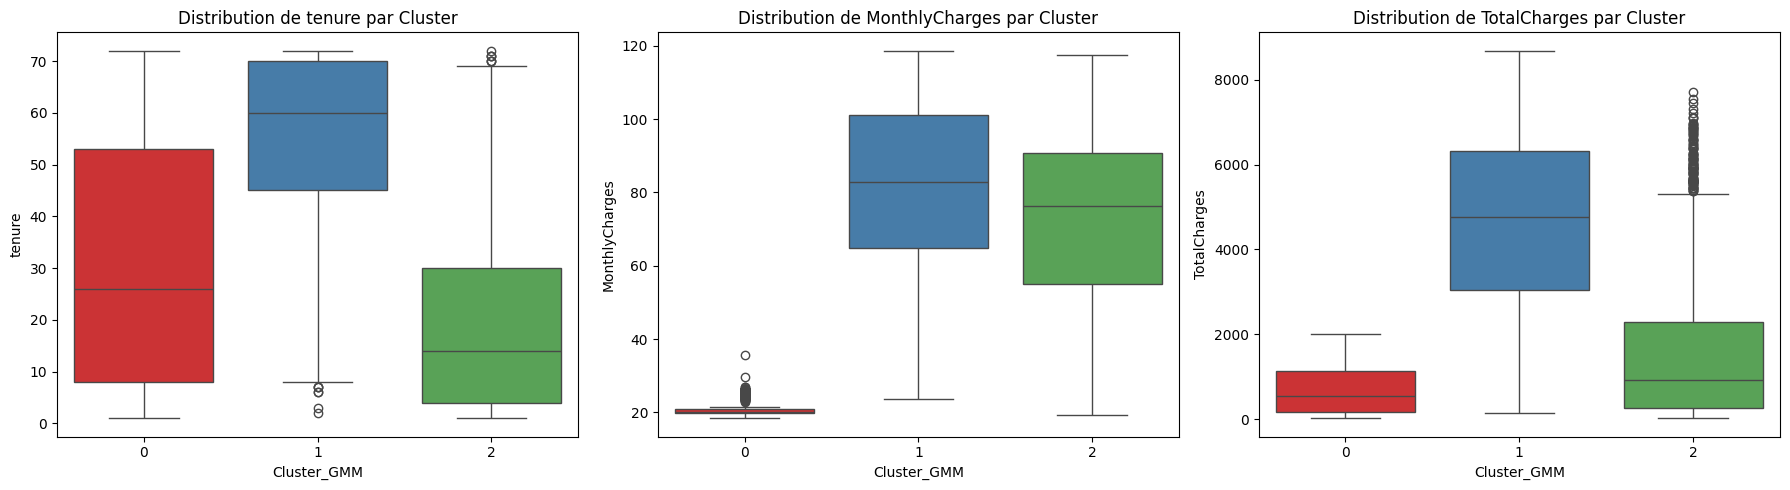

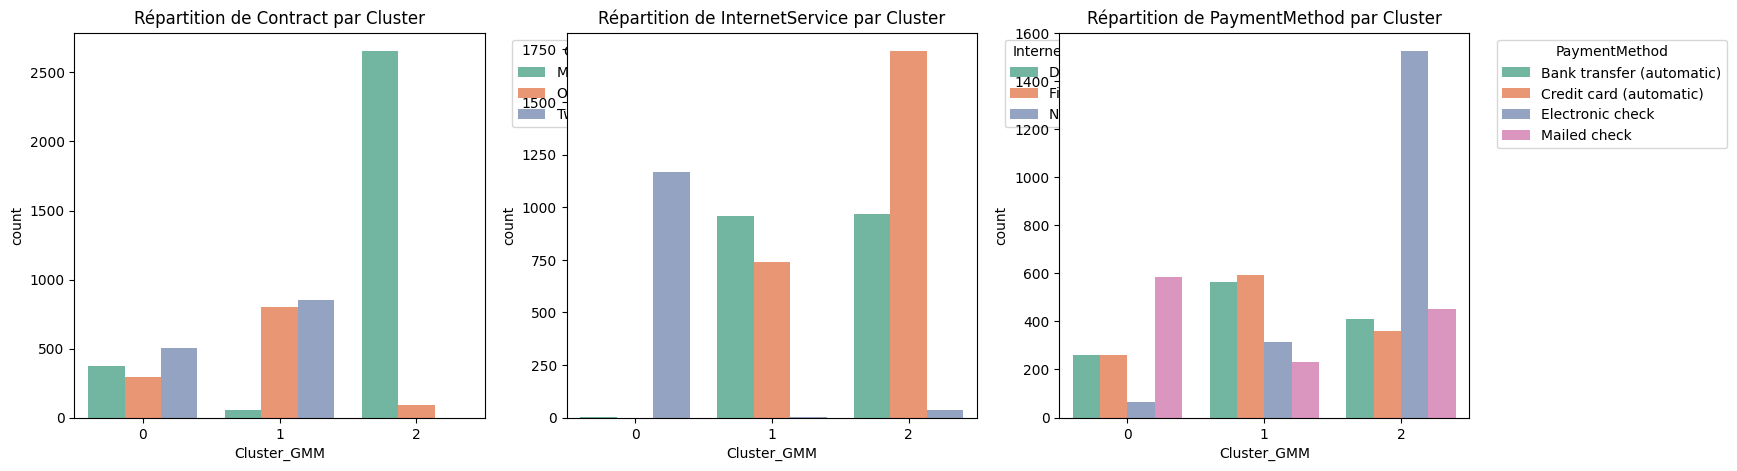

In [80]:
# --- COMPLÉMENT À L'APPRENTISSAGE NON SUPERVISÉ : CARACTÉRISATION DES CLUSTERS ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("PROFILAGE DES CLUSTERS GMM (DÉCISION FINALE)")

# 1) Création d'un dataset de profilage
# On utilise X_train (les données brutes d'entraînement) pour pouvoir interpréter les vraies valeurs
# on copie par securite pour pas casser le pipeline de ML
df_profil = X_train.copy()

# On ajoute les labels générés par le GMM (parce uqe c'est le modele qu'o  a choisi)
df_profil['Cluster_GMM'] = clusters_gmm

# 2)Nettoyage rapide pour la lecture numérique (TotalCharges est parfois vu comme du texte)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    if col in df_profil.columns:
        df_profil[col] = pd.to_numeric(df_profil[col], errors='coerce')

# 3)Analyse des variables numériques (moyennes par cluster GMM)
print("\n--- Moyennes des variables numériques par Cluster ---")
profil_num = df_profil.groupby('Cluster_GMM')[numeric_cols].mean()
display(profil_num)

# 4)viualistion des variables numériques (boxplots)
plt.figure(figsize=(18, 5))
for i, col in enumerate(numeric_cols, 1):
    if col in df_profil.columns:
        plt.subplot(1, 3, i)
        sns.boxplot(x='Cluster_GMM', y=col, data=df_profil, palette='Set1')
        plt.title(f'Distribution de {col} par Cluster')
plt.tight_layout()
plt.show()

# 5) Analyse des variables catégorielles
#On verifie les preferences de haque groupe
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod']

plt.figure(figsize=(18, 5))
for i, col in enumerate(categorical_cols, 1):
    if col in df_profil.columns:
        plt.subplot(1, 3, i)
        sns.countplot(x='Cluster_GMM', hue=col, data=df_profil, palette='Set2')
        plt.title(f'Répartition de {col} par Cluster')
        plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Observations :    

Nous avons réalisé ces visualisation afin d'avoir les carctéristiques de chaque groupes, c'est à dire là où chacun se démarque. Pour y voir plus clair on va bien indiquer groupe par groupe là où ils ont des particularités :

####Cluster 0 :    
- a la tenure la plus étendu des 3 clusters, dasn le sens où il y a plusieurs personnes étant présents que depus peu que de persnnes présentes depuismodérément longtemps, là où les autres clusters semblent soient avoir une grande majorité des personnes présentes depuis très longtmeps ou une grande majorité présente depuis peu de temps, à quelques exception près.

- A les MonthlyCharges les + basses (différence flagrante avec les autres clusters)
- Ses Total Charges sont parmis les plus basses et dépassent jamais celles des autres clusters

- Les durées de contrats ne semblent pas être un grande facteur, il ya presque autant de month to month que de one year ou 2 years

- Seule une VRAIMENT MINUSCULE partie d'entre eux a une ofre DSL, autrement la quasi totalité d'entre eux n'ont aucun service internet souscrit

- presque aucun d'entre eux ne paye par "Elecctornik check", ils sont cependant le cluster qui paye le plus par "mailed chack"

####Cluster 1 :    

- ils ont la tenure qui est la plus grande en moyenne que les autres clusters

- ls ont les monthlycharges qui sont les plus grands en moyenne que les autres clusters (même si ceux du clusters 2 ne sont tant que ça éloig
né de ceux du cluster 1)

- ils sont ceux qui ont les TotalCharges les plus élevées en moyenne comparé aux autres clusters

- ils sont ceux qui ont le moins de contrat "month-to-month", et également ceux qui ont le plus de contrats "1 year" et "2 years"

- On peut remarque que leur groupe souscrit généralement soit un forfait DSL ou Fibre Optique, et presque aucun d'entre eu ne souscirvnent aucun service internet

- On peut remarquer qu'ils sont ceux qui paient le plus par transfert bancaire ou carte bancaireet que moins souvent (mais toujours assez présent pour que ce ne soit pas vu comme une petite minorité) certains d'entre eux paient par elecronic check et mailed check



####Cluster 2 :     

- Ce cluster contient les gens qui ont la moyenne d'ancienneté (tenure) la plus basse comparé aux autres clusters (des personnes du cluster 0 ont également des tenure faibles comme le cluster 2 mais ce cluster est étendu et contient des personnes à ancienneté modérément grande contraire à ce cluster qui n'est que peu élevé)

- Leurs MonthLyCharges sont presque en moyenne aussi élevé que ceux du cluster 1 (celui qui a les monthlycharges les plus élevées), par contre leur total charges sont parmis les plus basses (pouvant s'expliquer par leur faible ancienneté vu dans le premier tiret)

- Aucun d'entre eux n'a de contrat en 2 year, une minorité d'entre eux a un contrat en 1 year (c'est le cluster qui en compte le moins) et la majorité d'entre eux a un contrat en one month, ils sont le cluster qui a DE LOIN le plus d'abonnement en month-to-month

- Ils sont ceux qui commendent de loin le plus de fibres optiques, un nombre moyen d'entre eux a un service DSL, et seulse une petite minorité d'entre n'ont pas de service internet

- ils sont ceux qui payet le plus par cheque élecroniquescomparé à tous les clusters, , sinon ils payent de tous les autres moyens sans trop de variations entre les fréquences de paiement entre chacun de ces moyens de paiment

###Conclusion et profile type par cluster :    

- Cluster 0 - Les abonnés téléphoniques : Ce cluster rassemble les personnes souscrivant pour la majorité uniquement à des services téléphoniques, leurs charges mensuelles comme totales sont en conséquences peu élevées comparés aux personnes d'autres clusters, il peut y avaoir de nouveaux clients en leur sein tout comme des clients de relativement longue date.

- Cluster 1 - Les clients de longue date, utilisateurs de services internet : ce cluster rassemble un groupe de personnes étant les clients présent en moyennes depuis plus longtemps, des clients fidélisés donc, et qui souscrivent des abonnements les engageant sur de plus longues périodes ils ont pour la quasi totalité d'entre eux tous souscirt à une offre internet et sont ceux qui ont payé le plus nos services, de par leur ancienneté et le prix plus élevé de leurs services souscrits.

- Cluster 2 - Les nouveaux arrivants / en période d'essai : Ce cluster contient des personnes ayant une ancienneté en moyenne plutot récente, ou commençant tout juste à avoir une ancienneté "commençant à devenir modérément ancienne". Ils sont la catégorie payant le plus d'abonnement mensuels et presque pas à l'année (jamais d'abonnement en 2 ans), et ils représentent également les plus grands consommateurs d'offres de fibre optique offerts par nore entreprise. , très peu d'entre-eux ne suscrivent pas d'offre internet.Les clients représentés par ce cluster sont des clients généralement récemment arrivés, qui ont été séduit par nos offres internet (et majoritairement notre offre de fibre optique)et ne s'étant pas engagé dans des contrats de longue durée avec notre entreprise, afin de pouvoir se rétracter si l'offre ne leur convient finalement pas, on peut considérer qu'ils sont potentiellement encore dasn une phase "d'essai" de nos produit.


#Analyse Business et Impact

1. Stratégie :    

Etant donné que chacun de nos clusters sont des profils bien distincts d'utilisateur, nous voulons mettre en place une stratégie différente selon l'appartenance des utilisateur à l'un des clusters, de sorte que si l'un d'entre eux semble sur le point de nous quitter, nous mettions en place la stratégie adaptée à son profil.

- Stratégie pour cluster 0 : Ces clients ne souscrivent généralement que le téléphone, en leur proposant des offre des pack / offres groupées (par exemple des forfaits avec réduction s'ils souscrivent à une offre internet tout en étant déjà client chez nous pour leur téléphone), cela pourrait leur donner une raison de plus de rester client chez-nous car l'association de deux offres à prix avantageux serasuffisamment compétitive pour dissuader d'aller chez des concurrents. De même, cela pourra nous avantager, car ça aménerait les clients y adhérant à dépenser davantage pour nos serices que lorsqu'ils ne souscrivaient qu'une offre téléphonique.

- Stratégie pour cluster 1 : Ce cluster rassemble nos clients les plus fidèles et sûrs, ils sont ceux qui ont le plus dépensés chez nous de par la fait de leur ancienneté couplée au faait qu'ils ont presque tous souscrit à nos offres internet. La stratégie serait alors de ne pas les oublier car leur perte serait très regretable, et une concurrence qui leur offrirait des avantages plus important pourrait éventuellement les convaincre de nous quitter. Nous pourrions alors mettre en place un système de récompense : leur ancienneté pourrait leur conférer des avantages exclusives comme par exmeple le fait de leur offrir une option supplémentaire ou des réductions sur une des options, même si cela ne dûre que quelques mois. Cela coutera moins cher que de perdre les paiements qu'ils nous auraient fait s'ils étaient resté chez nous encore des années.

- Startégie pour cluster 2 : Ce cluster représente tous les nouveaux arrivants au sein de notre clientèle, clients qui sont encore en phase de "test" de nos services. Ils sont le cluster à cibler de manière prioritaire car ils représentent les clients les plus à risque de nous quitter en terme de churn, ils dépensent plus car ils prennent souvent aussi des offres internet, et particulièrement de fibre, mais ils ont souvent des contrat de court termes : en month to month, faisant qu'ils pourraient nous quitter d'un mois à l'autre. La stratégie pourrait être que dès que l'on voit un risque de churn pour l'un d'entre eux (l'interface de l'API est très bein pour ça), il faut que nous ciblions dès que possible cette personnes pour lui proposer des réductions ou offres groupées téléphoniques (si certains d'entre eux n'en souscrivent pas) ou encore proposer des offres groupées avec réduction aux clients n'ayant pas souscrit d'offre internet, meême si elles sont minoritaires pour ce cluster. Leur fidélisation est primordiale pour permette à ces nouveaux clients de devenir les prochain clients de longue dates, comme représenté dans le cluster 1.


2. Impact métier :
La mise en place de notre solution aura plusieurs impacts sur la réalité métier de notre entreprise :  

- L'entreprise n'aura plus à subir passivement les résiliations et aura ls cartes en main pour pouvoir anticiper et agir avant qu'un client ne résilie.

- Une possible réduction des coût sera possible pour l'enteprise car ça coute plus cher et c'est plus incertain de trouver de nouveaux clients alors que sécuriser ceux qu'on a déjà / les fidéliser sera moins coûteux, surtout si on se concente sur le fait de proposer des offres  ceux qu'on prédit comme des clients susceptibles de partir.

- Etant donné que les lcients du cluster 2 sont les plus suscptibles de partir mais également un cluster qui payent les offres les plus onéreuses, se concentrer sur la fidélisation de ces clients permettrait d'assurer à notre entreprise d'avoir davantage de clients de longue date qui paient des offres parmis nos plus haut prix. En effet, ces clients sont notre source de revenu la plus lucrative avec les clients de longue date du cluster 1.

3. Limites
Malgré tout notre traail rencontre quelques limites que nous allons mentionner ci-dessous :    
- Figé dans le temsp : notre dataset contient des données à un moment T, mais nous ne pouvons pas être sûre que ces données sont toujours d'actuaalité si nous n'avons apas de données mises à jour régulièrement/actuelles.

- Nous n'avons pas accès aux notes du service, aux données sur les possibles pannes recontrés par les utilisateurs.

- Bien que nous puissions proposer des stratégies marketing, nous ne sommes pas forcément sûrs que la stratégie marketing proposé par chaque client de chaque cluster fonctionnera, il faudra faire d'autres analyses par la suite, mais nous avous déjà une bonne base.

4. Perspectives

- Tester sur une petite partie de nos clients : nous pouvons ensuite tester nos stratégies sur une petite partie des clients uniquement afin de voir si nous voyons en effet des résultats positifs. Ainsi, s'il n'y a pas de résultat positif, nous n'auront pas commencé une campagne coûteuse d'envoie de promotions et de résuctions en vain.

- Nous pouvons enrichir nos données en les croisant avec notres dataset, comme par exemple celles du support technique et du services de réclamations, ainsi, nous aurons davantage de données que nous pourrons prendre en compte pour comprendre les problèmes que pourraient rencontrer nos services et qui expliqueraient le churn.

- Si nous pouvons mettre à jour  notre modèle existe régulièrement (chque mois par exemple) afin de pouvoir s'assurer qu'il se mette à jour pour se réentraîner avec de nouvelles données récoltées, cela permeettrait qu'il reste précis et ne devienne pas obsolète. Si une automatisation permettait que cela se fasse automatiquement, ce serait encore mieux.

### Sauvgarde du modèle optimisé et du preprocessor pour API

In [81]:
import joblib

# 1. On sauvegarde (on écrase) l'ancien modèle avec le nouveau modèle optimisé
joblib.dump(xgb_model, 'model.pkl')
print(" Modèle LogReg optimisé sauvegardé sous 'model.pkl'")

# Sauvegarde de ton pipeline de préparation des données (Le Traducteur)
joblib.dump(preprocessor, 'API/preprocessor.pkl')

print("Preprocessor sauvegardé avec succès sous le nom 'preprocessor.pkl' !")


 Modèle LogReg optimisé sauvegardé sous 'model.pkl'
Preprocessor sauvegardé avec succès sous le nom 'preprocessor.pkl' !
